<a href="https://colab.research.google.com/github/Haladar-Alert/DZ_math/blob/main/%D0%94%D0%97_7_k-NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/drive/1tElT3FhddabqCyJKFH27rhnyXJTqrzke?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K Nearest Neighbors (KNN)

## Introduction

The k Nearest Neighbors method (kNN) is a very popular classification method, also sometimes used in regression tasks. It's one of the most understandable approaches to classification. Intuitively, the essence of the method is: look at the neighbors; the predominant ones indicate what you are. Formally, the basis of the method is the compactness hypothesis: if the distance metric between examples is introduced successfully, then similar examples are much more likely to be in the same class than in different ones.

<img src='https://hsto.org/web/68d/a45/6f0/68da456f00f8434e87628dbe7e3f54a7.png' width=600>

 For the classification of each object in the test dataset, it is necessary to sequentially perform the following operations:
   * Calculate the distance to each of the objects in the training dataset.
   * Select objects from the training dataset to which the distance is minimal.
   * The class of the classified object is the class most frequently occurring among the k nearest neighbors.

We will work with a subset of the [Covertype dataset from the UCI repository](http://archive.ics.uci.edu/ml/datasets/Covertype). There are 7 different classes available. Each object is described by 54 features, 40 of which are binary. The data description is available at the link.

## Preprocessing

In [ ]:
import pandas as pd
import numpy as np

Press [here](https://drive.google.com/file/d/1Z39LNnF4lOj4iT48YDYFZNPDBglMd0TZ/view?usp=sharing) to download the dataset.

In [ ]:
all_data = pd.read_csv('datasets/forest_dataset.csv')
all_data.head()

In [ ]:
all_data.shape

Extract the class labels into a variable `labels`, and the feature descriptions into a variable `feature_matrix`. Since the data is numerical and does not have missing values, we will convert it to `numpy` format using the `.values` method.

In [ ]:
labels = all_data[all_data.columns[-1]].values
feature_matrix = all_data[all_data.columns[:-1]].values

## Train-test split

In [ ]:
from sklearn.model_selection import train_test_split

We will now work with all 7 types of cover (the data is already in the variables `feature_matrix` and `labels` if you haven't redefined them). Divide the sample into training and test sets using the `train_test_split` method.


In [ ]:
train_feature_matrix, test_feature_matrix, train_labels, test_labels = train_test_split(
    feature_matrix, labels, test_size=0.2, random_state=42)

The main objects in `sklearn` are the so-called `estimators`. They are divided into **classifiers** and **regressors**.

As examples of models, you can consider the classifiers
[k Nearest Neighbors](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) and
[logistic regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).

All models in `sklearn` must have at least 2 methods  -- `fit` and `predict`.
The `fit(X, y)` method is responsible for training the model and takes as input a training sample in the form of a *feature matrix* $X$ and a *response vector* $y$.

After `fit`, you can now call the `predict(X)` method on the trained model, which will return predictions of this model on all objects from the matrix $X$ in the form of a vector.

You can call `fit` on the same model several times; each time it will be trained anew on the given dataset.

Also, models have *hyperparameters*, which are usually set when creating the model.

Let's see all this on the example of logistic regression.


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf = LogisticRegression(C=1)
clf.fit(train_feature_matrix, train_labels)
y_pred = clf.predict(test_feature_matrix)

Now, we would like to measure the quality of our model. For this, we can use the `score(X, y)` method, which will calculate some error function on the sample $X, y$, but exactly which one depends on the model. Alternatively, one of the functions from the `metrics` module can be used, for example, [accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html), which, as the name suggests, will calculate the accuracy of predictions for us.


In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(test_labels, y_pred)

Finally, the last thing we would like to mention is grid search for hyperparameter tuning. Since models have many hyperparameters that can be changed, and the quality of the model significantly depends on these hyperparameters, it would be desirable to find the best parameters in this sense. The simplest way to do this is to just iterate over all possible variants within reasonable limits.

This can be done using the [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) class, which conducts a search (search) across a grid (grid) and calculates the quality of the model using cross-validation (CV).

For example, in logistic regression, you can change the `C` and `penalty` parameters. Let's do that. Keep in mind that the search may take a long time. Refer to the documentation for the meaning of the parameters.


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
clf = LogisticRegression(solver='saga')

# init GridSearchCV with parameters
param_grid = {
    'C': np.arange(1, 5),
    'penalty': ['l1', 'l2'],
}

search = GridSearchCV(clf, param_grid, n_jobs=-1, cv=5, refit=True, scoring='accuracy')

search.fit(feature_matrix, labels)

print(search.best_params_)

In this case, the search iterates over all possible pairs of values for `C` and `penalty` from the specified sets.


In [ ]:
accuracy_score(labels, search.best_estimator_.predict(feature_matrix))

Note that we pass the entire dataset to GridSearchCV, not just its training part. This can be done because the search still uses cross-validation. However, sometimes a *validation* part is still separated from the dataset, as the hyperparameters might overfit to the sample during the search process.

In the tasks, you will need to repeat this for the k Nearest Neighbors method.

# Homework

The quality of classification/regression by the k Nearest Neighbors method depends on several parameters:
* the number of neighbors `n_neighbors`
* the distance metric between objects `metric`
* the weights of neighbors (the neighbors of the test example can enter with different weights, for example, the further the example, the less its "voice" is taken into account) `weights`


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

file_path = '/content/drive/MyDrive/datasets/forest_dataset.csv'

# Загрузка данных
print(f"Загрузка данных из {file_path}...")
all_data = pd.read_csv(file_path)
print("Данные загружены.")

# Отделение меток (последний столбец) от признаков (все столбцы кроме последнего)
print("Отделение признаков и меток...")
labels = all_data[all_data.columns[-1]].values
feature_matrix = all_data[all_data.columns[:-1]].values
print("Признаки и метки отделены.")

# Разделение данных на обучающую и тестовую выборки
print("Разделение на обучающую и тестовую выборки...")
train_feature_matrix, test_feature_matrix, train_labels, test_labels = train_test_split(
    feature_matrix, labels, test_size=0.2, random_state=42, stratify=labels) # Добавил stratify для лучшего разделения
print("Разделение завершено.")

# Вывод размеров полученных матриц для проверки
print("\nРазмеры данных:")
print(f"Обучающая матрица признаков: {train_feature_matrix.shape}")
print(f"Тестовая матрица признаков:    {test_feature_matrix.shape}")
print(f"Обучающие метки:             {train_labels.shape}")
print(f"Тестовые метки:              {test_labels.shape}")

# Небольшая проверка содержимого
print("\nПервые 5 обучающих меток:", train_labels[:5])
print("Первые 5 тестовых меток:", test_labels[:5])
print(f"Уникальные метки: {np.unique(labels)}")

Mounted at /content/drive
Загрузка данных из /content/drive/MyDrive/datasets/forest_dataset.csv...
Данные загружены.
Отделение признаков и меток...
Признаки и метки отделены.
Разделение на обучающую и тестовую выборки...
Разделение завершено.

Размеры данных:
Обучающая матрица признаков: (8000, 54)
Тестовая матрица признаков:    (2000, 54)
Обучающие метки:             (8000,)
Тестовые метки:              (2000,)

Первые 5 обучающих меток: [7 2 1 2 1]
Первые 5 тестовых меток: [1 1 2 1 2]
Уникальные метки: [1 2 3 4 5 6 7]


In [3]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
import time # Для замера времени выполнения

# Создаем базовую модель KNeighborsClassifier
clf = KNeighborsClassifier()

# Задаем сетку параметров для перебора
params = {
    'n_neighbors': range(1, 11), # От 1 до 10 соседей
    'metric': ['manhattan', 'euclidean'], # Две метрики расстояния
    'weights': ['uniform', 'distance'] # Два способа взвешивания
}

# Создаем объект GridSearchCV
# cv=5 означает 5-кратную кросс-валидацию
# scoring='accuracy' - метрика для оценки качества
# n_jobs=-1 - использовать все доступные ядра процессора для ускорения
print("Параметры для проверки:", params)

start_time = time.time() # Засекаем время начала

clf_grid = GridSearchCV(clf, params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Обучаем GridSearchCV на обучающих данных
# Он автоматически переберет все комбинации параметров из 'params'
clf_grid.fit(train_feature_matrix, train_labels)

end_time = time.time() # Засекаем время окончания
print(f"\nПоиск завершен за {end_time - start_time:.2f} секунд.")

# Выводим лучшие найденные параметры
print("\nЛучшие параметры, найденные GridSearchCV:")
print(clf_grid.best_params_)

# Выводим лучшую оценку точности (accuracy) на кросс-валидации
print(f"\nЛучшая средняя точность на кросс-валидации: {clf_grid.best_score_:.4f}")

Параметры для проверки: {'n_neighbors': range(1, 11), 'metric': ['manhattan', 'euclidean'], 'weights': ['uniform', 'distance']}
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Поиск завершен за 70.89 секунд.

Лучшие параметры, найденные GridSearchCV:
{'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}

Лучшая средняя точность на кросс-валидации: 0.7714


In [6]:
optimal_clf = clf_grid.best_estimator_
print("Оптимальная модель (лучший estimator из GridSearchCV):")
print(optimal_clf)

y_pred_optimal = optimal_clf.predict(test_feature_matrix)
test_accuracy = accuracy_score(test_labels, y_pred_optimal)
print(f"Точность на тестовой выборке: {test_accuracy:.4f}")

pred_prob = optimal_clf.predict_proba(test_feature_matrix)

print(f"\nРазмер матрицы вероятностей: {pred_prob.shape}")

# Посмотрим на вероятности для первых нескольких тестовых примеров
print("\nВероятности для первых 5 тестовых примеров:")
np.set_printoptions(precision=4, suppress=True)
print(pred_prob[:5])

Оптимальная модель (лучший estimator из GridSearchCV):
KNeighborsClassifier(metric='manhattan', n_neighbors=4, weights='distance')
Точность на тестовой выборке: 0.7825

Размер матрицы вероятностей: (2000, 7)

Вероятности для первых 5 тестовых примеров:
[[1.     0.     0.     0.     0.     0.     0.    ]
 [0.7284 0.2716 0.     0.     0.     0.     0.    ]
 [0.2149 0.7851 0.     0.     0.     0.     0.    ]
 [0.7621 0.2379 0.     0.     0.     0.     0.    ]
 [0.2409 0.7591 0.     0.     0.     0.     0.    ]]


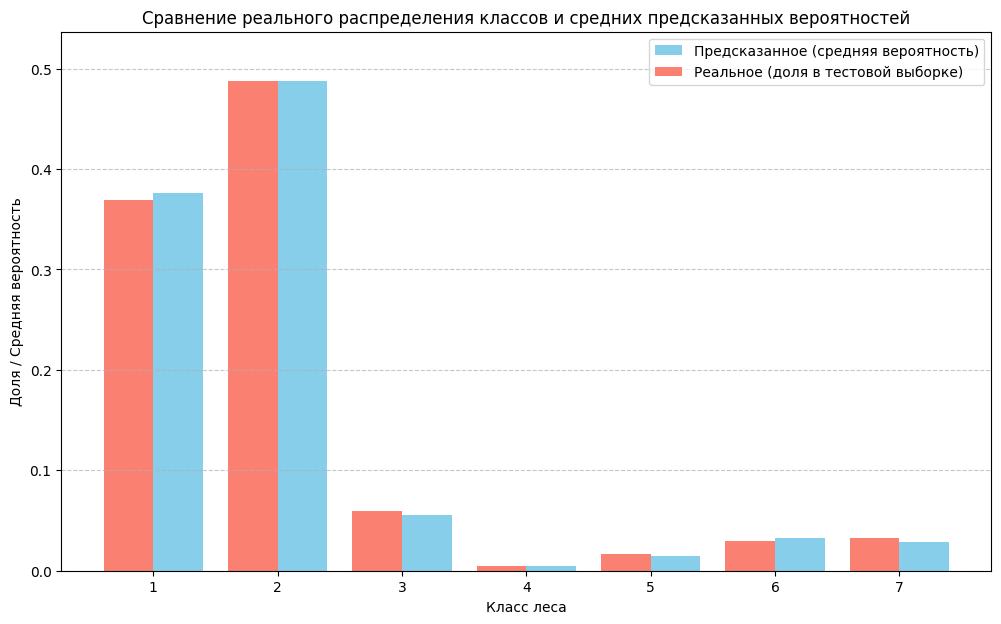


Сравнение частот:
Класс | Реальн. доля | Предсказ. ср. вер.
---------------------------------------
  1   |   0.3690    |     0.3764
  2   |   0.4875    |     0.4880
  3   |   0.0590    |     0.0559
  4   |   0.0050    |     0.0044
  5   |   0.0165    |     0.0146
  6   |   0.0300    |     0.0321
  7   |   0.0330    |     0.0287


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Рассчитать реальную частоту каждого класса в тестовой выборке
unique_classes, class_counts = np.unique(test_labels, return_counts=True)
# Преобразуем количество в частоту (долю)
real_freq = class_counts / len(test_labels)

# 2. Рассчитать среднюю предсказанную вероятность для каждого класса
pred_freq = pred_prob.mean(axis=0)

# 3. Построить столбчатую диаграмму для сравнения
plt.figure(figsize=(12, 7)) # Размер графика

# Номера классов для оси X (от 1 до 7)
class_numbers = range(1, len(unique_classes) + 1)

# Ширина столбцов
bar_width = 0.4

# Строим столбцы для предсказанных частот (сдвинуты вправо)
plt.bar(class_numbers, pred_freq, width=bar_width, align='edge', label='Предсказанное (средняя вероятность)', color='skyblue')

# Строим столбцы для реальных частот (сдвинуты влево)
plt.bar(class_numbers, real_freq, width=-bar_width, align='edge', label='Реальное (доля в тестовой выборке)', color='salmon')

# Настройка графика
plt.xlabel('Класс леса')
plt.ylabel('Доля / Средняя вероятность')
plt.title('Сравнение реального распределения классов и средних предсказанных вероятностей')
plt.xticks(class_numbers)
plt.ylim(0, max(real_freq.max(), pred_freq.max()) * 1.1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Выведем также численные значения для сравнения
print("\nСравнение частот:")
print("Класс | Реальн. доля | Предсказ. ср. вер.")
print("---------------------------------------")
for i, cls_num in enumerate(unique_classes):
    print(f"  {cls_num}   |   {real_freq[i]:.4f}    |     {pred_freq[i]:.4f}")

## Conclusion

What is the quality of the model on the test sample? Compare it with the quality of logistic regression. Which model is better? Why? What are the pros and cons of the k Nearest Neighbors method? Plot the ROC curve for the k Nearest Neighbors method. Calculate the area under the ROC curve (AUC-ROC).

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import time


log_reg = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)


params_log_reg = {
    'C': [0.01, 0.1, 1, 10, 100]
}

# Создаем GridSearchCV для Логистической Регрессии
start_time_lr = time.time()

log_reg_grid = GridSearchCV(log_reg, params_log_reg, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Обучаем GridSearchCV на ТЕХ ЖЕ ОБУЧАЮЩИХ ДАННЫХ, что и k-NN
log_reg_grid.fit(train_feature_matrix, train_labels)

end_time_lr = time.time()
print(f"\nПоиск для Лог. Регрессии завершен за {end_time_lr - start_time_lr:.2f} секунд.")

# Получаем лучшую модель Логистической Регрессии
optimal_log_reg = log_reg_grid.best_estimator_
print("\nЛучшая модель Логистической Регрессии:")
print(optimal_log_reg)
print(f"Лучший параметр C: {log_reg_grid.best_params_['C']}")
print(f"Лучшая средняя точность LogReg на кросс-валидации: {log_reg_grid.best_score_:.4f}")

# Оценим точность оптимальной Логистической Регрессии на ТЕСТОВОЙ выборке
y_pred_log_reg = optimal_log_reg.predict(test_feature_matrix)
test_accuracy_log_reg = accuracy_score(test_labels, y_pred_log_reg)
print(f"Точность Логистической Регрессии на тестовой выборке: {test_accuracy_log_reg:.4f}")

# Сравнение с k-NN
print("\n--- Сравнение моделей ---")
print(f"Точность k-NN на тесте:       {test_accuracy:.4f}") # test_accuracy из предыдущего шага
print(f"Точность LogReg на тесте:   {test_accuracy_log_reg:.4f}")

if test_accuracy > test_accuracy_log_reg:
    print("Модель k-NN показала лучшую точность на тестовых данных.")
elif test_accuracy_log_reg > test_accuracy:
     print("Модель Логистической Регрессии показала лучшую точность на тестовых данных.")
else:
     print("Обе модели показали одинаковую точность на тестовых данных.")

Fitting 5 folds for each of 5 candidates, totalling 25 fits

Поиск для Лог. Регрессии завершен за 78.86 секунд.

Лучшая модель Логистической Регрессии:
LogisticRegression(C=100, max_iter=1000, random_state=42)
Лучший параметр C: 100
Лучшая средняя точность LogReg на кросс-валидации: 0.6845
Точность Логистической Регрессии на тестовой выборке: 0.6900

--- Сравнение моделей ---
Точность k-NN на тесте:       0.7825
Точность LogReg на тесте:   0.6900
Модель k-NN показала лучшую точность на тестовых данных.


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Какая модель лучше (k-NN или Логистическая Регрессия) и почему - Вот в чем вопрос?**

* **Лучшая модель:** k-NN (точность = 0.78) значительно превзошла Логистическую Регрессию (точность = 0.69) на этом наборе данных.
* **Почему:** Наверное потому что данные имеют **нелинейную структуру**. k-NN хорошо улавливает сложные, локальные зависимости между объектами, так как опирается на ближайших соседей. Логистическая регрессия ищет линейную разделяющую границу, что как видемо не подходит из-за не линейности.

**Плюсы и минусы метода k-ближайших соседей (k-NN):**

* **Плюсы:**
    - **Простота:** Легко понять и реализовать.
    - **Гибкость:** Не требует предположений о форме данных, может находить нелинейные закономерности.
    - **Нет обучения:** Не требует отдельного этапа обучения (только хранение данных).
* **Минусы:**
    - **Медленное предсказание:** Нужно считать расстояния до многих точек при каждом предсказании (особенно на больших данных).
    - **Память:** Требует хранения всей обучающей выборки.
    - **Чувствительность к масштабу:** Нуждается в масштабировании признаков.
    - **Чувствительность к шуму:** Выбросы могут сильно влиять на результат.
    - **Выбор 'k':** Результат зависит от правильного подбора числа соседей 'k'.
    - **Макро слабость:** Плохо работает при очень большом количестве признаков.

<ipython-input-9-53806efdee95>:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes) # Используем цветовую карту 'tab10'


Расчет и построение ROC-кривых (One-vs-Rest)...


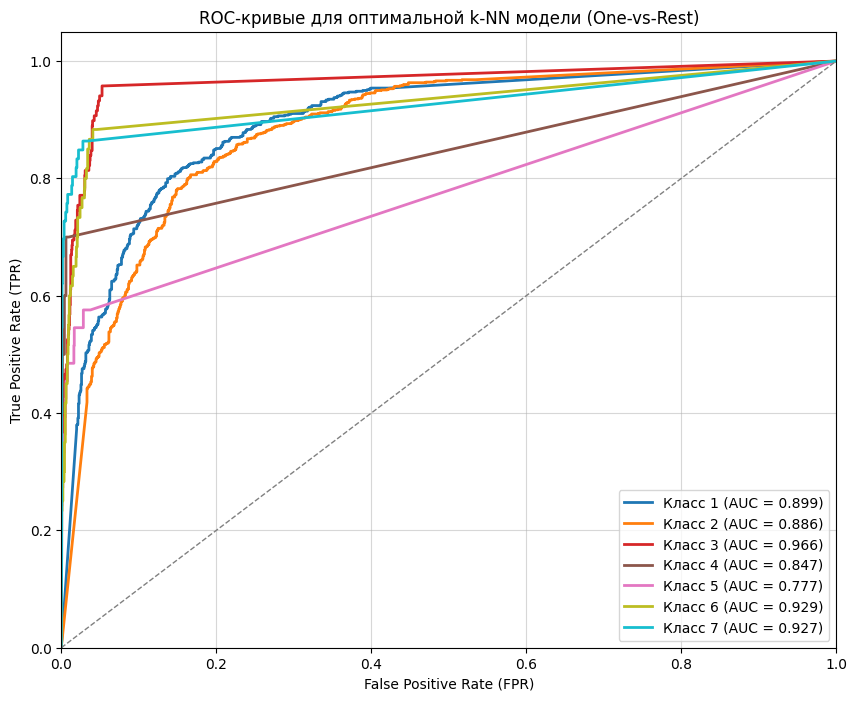


Расчет общих AUC-ROC:
AUC-ROC (Macro average): 0.8901
AUC-ROC (Micro average): 0.9525


In [9]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

# У нас есть:
# test_labels - реальные метки тестовой выборки
# pred_prob - вероятности, предсказанные оптимальной k-NN моделью (optimal_clf)
# unique_classes = np.unique(test_labels) # Классы от 1 до 7
n_classes = len(unique_classes)

# Настройка цветов для графика (не обязательно, но делает красивее)
colors = plt.cm.get_cmap('tab10', n_classes) # Используем цветовую карту 'tab10'

plt.figure(figsize=(10, 8)) # Размер графика

print("Расчет и построение ROC-кривых (One-vs-Rest)...")

# Цикл по каждому классу (от 1 до 7)
for i, class_id in enumerate(unique_classes):
    # 1. Создаем бинарные метки: 1 для текущего класса, 0 для всех остальных
    y_true_binary = (test_labels == class_id)

    # 2. Берем вероятности для текущего класса (столбец i)
    y_score = pred_prob[:, i]

    # 3. Рассчитываем точки ROC-кривой
    fpr, tpr, thresholds = roc_curve(y_true_binary, y_score)

    # 4. Рассчитываем AUC
    roc_auc = auc(fpr, tpr)

    # 5. Строим ROC-кривую для текущего класса
    plt.plot(fpr, tpr, color=colors(i), lw=2,
             label=f'Класс {class_id} (AUC = {roc_auc:.3f})') # AUC с 3 знаками после запятой

# Рисуем диагональную линию (соответствует случайному угадыванию)
plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--')

# Настраиваем и показываем график
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05]) # Чуть выше 1.0, чтобы легенда не перекрывала кривые
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривые для оптимальной k-NN модели (One-vs-Rest)')
plt.legend(loc="lower right") # Размещаем легенду внизу справа
plt.grid(alpha=0.5) # Добавляем сетку
plt.show()

# Дополнительно: Рассчитаем общие AUC (Macro и Micro)
# Macro - среднее AUC по всем классам (каждый класс одинаково важен)
# Micro - общая AUC, вычисленная по всем предсказаниям вместе (важнее общая производительность)
print("\nРасчет общих AUC-ROC:")
try:
    auc_macro = roc_auc_score(test_labels, pred_prob, multi_class='ovr', average='macro')
    auc_micro = roc_auc_score(test_labels, pred_prob, multi_class='ovr', average='micro')
    print(f"AUC-ROC (Macro average): {auc_macro:.4f}")
    print(f"AUC-ROC (Micro average): {auc_micro:.4f}")
except ValueError as e:
     print(f"Не удалось рассчитать общие AUC: {e}")
     # Это может случиться, если какой-то класс полностью отсутствует в test_labels,
     # но в нашем случае это маловероятно после stratify